In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [47]:
from pathlib import Path
import joblib

# === Directories for linear AR models and results ===
BASE_DIR = Path("../")  # adjust if needed

LIN_MODELS_DIR = BASE_DIR / "models" / "linear_ar"
LIN_RESULTS_DIR = BASE_DIR / "results" / "linear_ar"

LIN_MODELS_DIR.mkdir(parents=True, exist_ok=True)
LIN_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Linear models dir :", LIN_MODELS_DIR)
print("Linear results dir:", LIN_RESULTS_DIR)


Linear models dir : ..\models\linear_ar
Linear results dir: ..\results\linear_ar


In [2]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [3]:
# adjust paths if needed
features = pd.read_parquet("../../data/processed/market_all_features_with_sentiment.parquet")
features.head()

,date,open,high,low,close,volume,adj close,ticker,sector,cap,return,log_return,year,vol21,vol63,ret_ema21,ret_ema63,px_ma21,px_ma63,px_ma200,trend200_up,sent_mean,sent_std,sent_count,sent_pos,sent_neg,sent_neu,sent_daily_cat,sent_lag1,sent_cat_lag1,sent_roll3,row_id,is_train,set
0,2018-01-04,19.838642,19.958017,19.749111,19.935635,5738092.0,19.935635,ABB,Real Estate - Energy - Industrials,Mid Cap,0.010972,0.010913,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000,0.0,0.0,0.0,0.0,0.0,neutral,0.0,None,0.000000,ABB|2018-01-04,True,train
1,2018-01-04,7.882366,7.882366,7.882366,7.882366,0.0,7.882366,ALPINE,Consumer Discretionary,Large Cap,0.000000,0.000000,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000,0.0,0.0,0.0,0.0,0.0,neutral,0.0,None,0.000000,ALPINE|2018-01-04,True,train
2,2018-01-04,332.666046,333.091339,317.440460,323.224487,111998.0,323.224487,ARYZTA,Consumer Staples,Mid Cap,-0.024390,-0.024693,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.946913,0.0,1.0,1.0,0.0,0.0,positive,0.0,None,0.999941,ARYZTA|2018-01-04,True,train
3,2018-01-04,107.037628,107.741360,106.545007,107.670982,111416.0,107.670982,BALOISE,Insurance,Mid Cap,0.009235,0.009192,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000,0.0,0.0,0.0,0.0,0.0,neutral,0.0,None,0.000000,BALOISE|2018-01-04,True,train
4,2018-01-04,47.071196,47.562372,47.071196,47.480511,19374.0,47.480511,BKW ENERGIE,Real Estate - Energy - Industrials,Small Cap,0.003460,0.003454,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.041373,0.0,1.0,0.0,0.0,1.0,neutral,0.0,None,0.995683,BKW ENERGIE|2018-01-04,True,train


In [4]:
news_counts = features.groupby("ticker")["sent_count"].sum().sort_values(ascending=False)
news_counts


ticker
UBS                 30518.0
SWISSCOM             7052.0
NESTLE               5541.0
VONTOBEL             3208.0
BKW ENERGIE          3164.0
ABB                  3140.0
JULIUS BAER          2717.0
HELVETIA             2216.0
LONZA                2065.0
SWATCH               1952.0
SWISS LIFE           1928.0
SWISS RE             1761.0
HOLCIM               1630.0
ZURICH INSURANCE     1319.0
EMMI                 1297.0
RICHEMONT            1264.0
LOGITECH              969.0
BALOISE               895.0
SWISSQUOTE            887.0
ARYZTA                800.0
GIVAUDAN              770.0
LANDIS                770.0
BLKB                  526.0
SWISS PRIME SITE      438.0
ROCHE                 320.0
NOVARTIS              279.0
ALCON                 240.0
SANTHERA               97.0
ALPINE                 73.0
REISHAUER              67.0
Name: sent_count, dtype: float64

In [5]:
THRESHOLD = 1800
eligible_tickers = news_counts[news_counts >= THRESHOLD].index.tolist()
eligible_tickers


['UBS',
 'SWISSCOM',
 'NESTLE',
 'VONTOBEL',
 'BKW ENERGIE',
 'ABB',
 'JULIUS BAER',
 'HELVETIA',
 'LONZA',
 'SWATCH',
 'SWISS LIFE']

In [6]:
features = features[features["ticker"].isin(eligible_tickers)].copy()

In [7]:
sent_cols = [
    "sent_mean", "sent_std", "sent_count",
    "sent_pos", "sent_neg", "sent_neu",
    "sent_lag1", "sent_roll3"
]
for col in sent_cols:
    # .transform ensures output index matches the original DataFrame
    features[col] = (
        features
        .groupby("ticker")[col]
        .transform(lambda x: x.ffill(limit=1))
    )

In [8]:
# If some entries are the string "None", turn them into real NaN first (just in case)
features["sent_cat_lag1"] = features["sent_cat_lag1"].replace("None", np.nan)

# 1) Category lag: treat missing as NEUTRAL
features["sent_cat_lag1"] = features["sent_cat_lag1"].fillna("neutral")

# 2) Numeric lag: treat missing as 0 (neutral score)
features["sent_lag1"] = features["sent_lag1"].fillna(0.0)

# 3) Rolling sentiment: also neutral when missing
features["sent_roll3"] = features["sent_roll3"].fillna(0.0)

# Quick check
print(features[["sent_daily_cat", "sent_lag1", "sent_cat_lag1", "sent_roll3"]].head())
print(features[["sent_cat_lag1"]].isna().sum())


   sent_daily_cat  sent_lag1 sent_cat_lag1  sent_roll3
0         neutral        0.0       neutral    0.000000
4         neutral        0.0       neutral    0.995683
8         neutral        0.0       neutral    0.000000
10        neutral        0.0       neutral    0.000000
13        neutral        0.0       neutral    0.000000
sent_cat_lag1    0
dtype: int64


In [9]:
features.head()

,date,open,high,low,close,volume,adj close,ticker,sector,cap,return,log_return,year,vol21,vol63,ret_ema21,ret_ema63,px_ma21,px_ma63,px_ma200,trend200_up,sent_mean,sent_std,sent_count,sent_pos,sent_neg,sent_neu,sent_daily_cat,sent_lag1,sent_cat_lag1,sent_roll3,row_id,is_train,set
0,2018-01-04,19.838642,19.958017,19.749111,19.935635,5738092.0,19.935635,ABB,Real Estate - Energy - Industrials,Mid Cap,0.010972,0.010913,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000,0.0,0.0,0.0,0.0,0.0,neutral,0.0,neutral,0.000000,ABB|2018-01-04,True,train
4,2018-01-04,47.071196,47.562372,47.071196,47.480511,19374.0,47.480511,BKW ENERGIE,Real Estate - Energy - Industrials,Small Cap,0.003460,0.003454,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.041373,0.0,1.0,0.0,0.0,1.0,neutral,0.0,neutral,0.995683,BKW ENERGIE|2018-01-04,True,train
8,2018-01-04,77.012849,77.152363,76.454783,76.943092,124560.0,76.943092,HELVETIA,Insurance,Small Cap,0.004554,0.004543,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000,0.0,0.0,0.0,0.0,0.0,neutral,0.0,neutral,0.000000,HELVETIA|2018-01-04,True,train
10,2018-01-04,43.585963,44.323483,43.585963,44.193333,1034411.0,44.193333,JULIUS BAER,Banking,Large Cap,0.014608,0.014503,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000,0.0,0.0,0.0,0.0,0.0,neutral,0.0,neutral,0.000000,JULIUS BAER|2018-01-04,True,train
13,2018-01-04,255.671383,257.276422,252.838982,253.971954,378903.0,253.971954,LONZA,Health Care,Small Cap,-0.002965,-0.002970,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000,0.0,0.0,0.0,0.0,0.0,neutral,0.0,neutral,0.000000,LONZA|2018-01-04,True,train


## Create target and lag features

In [10]:
# === 1) Ensure correct ordering ===
# (date should already be datetime, but this is safe)
features["date"] = pd.to_datetime(features["date"], errors='coerce')

# Sort by ticker and date to make all shifts deterministic
features = features.sort_values(["ticker", "date"]).reset_index(drop=True)

# We'll work on a copy for modeling features
features_model = features.copy()

# === 2) Target: next-day return per ticker (t+1) ===
features_model["target_ret_next"] = features_model.groupby("ticker")["return"].shift(-1)

# === 3) Autoregressive lags of return (AR(5) style) ===
for lag in range(1, 6):
    features_model[f"ret_lag{lag}"] = features_model.groupby("ticker")["return"].shift(lag)

# === 4) Optional: lagged volatility (21-day) ===
features_model["vol21_lag1"] = features_model.groupby("ticker")["vol21"].shift(1)

# (⚠️ Do NOT drop NaNs yet; we will drop them
#  separately in train/test to keep the split consistent.)

print(features_model.shape)
features_model[[
    "date", "ticker",
    "return", "target_ret_next",
    "ret_lag1", "ret_lag2", "ret_lag3", "ret_lag4", "ret_lag5",
    "vol21", "vol21_lag1"
]].head(10)


(19338, 41)


,date,ticker,return,target_ret_next,ret_lag1,ret_lag2,ret_lag3,ret_lag4,ret_lag5,vol21,vol21_lag1
0,2018-01-04,ABB,0.010972,0.007485,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-01-05,ABB,0.007485,0.000372,0.010972,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-01-08,ABB,0.000372,0.005199,0.007485,0.010972,NaN,NaN,NaN,NaN,NaN
3,2018-01-09,ABB,0.005199,-0.007019,0.000372,0.007485,0.010972,NaN,NaN,NaN,NaN
4,2018-01-10,ABB,-0.007019,0.001116,0.005199,0.000372,0.007485,0.010972,NaN,NaN,NaN
5,2018-01-11,ABB,0.001116,0.008175,-0.007019,0.005199,0.000372,0.007485,0.010972,NaN,NaN
6,2018-01-12,ABB,0.008175,-0.007003,0.001116,-0.007019,0.005199,0.000372,0.007485,NaN,NaN
7,2018-01-15,ABB,-0.007003,0.005939,0.008175,0.001116,-0.007019,0.005199,0.000372,NaN,NaN
8,2018-01-16,ABB,0.005939,-0.012546,-0.007003,0.008175,0.001116,-0.007019,0.005199,NaN,NaN
9,2018-01-17,ABB,-0.012546,0.002242,0.005939,-0.007003,0.008175,0.001116,-0.007019,NaN,NaN


### Build train / test modeling DataFrames using existing split 

In [11]:
# Sanity: check that 'set' is still present
features_model[["set"]].value_counts()

set  
train    13827
test      5511
Name: count, dtype: int64

In [12]:
# 2.1 Create train/test based on fixed split
train_df = features_model[features_model["set"] == "train"].copy()
test_df  = features_model[features_model["set"] == "test"].copy()

In [13]:
train_df.ticker.value_counts()

ticker
ABB            1257
BKW ENERGIE    1257
HELVETIA       1257
JULIUS BAER    1257
LONZA          1257
NESTLE         1257
SWATCH         1257
SWISS LIFE     1257
SWISSCOM       1257
UBS            1257
VONTOBEL       1257
Name: count, dtype: int64

In [14]:
test_df.ticker.value_counts()

ticker
ABB            501
BKW ENERGIE    501
HELVETIA       501
JULIUS BAER    501
LONZA          501
NESTLE         501
SWATCH         501
SWISS LIFE     501
SWISSCOM       501
UBS            501
VONTOBEL       501
Name: count, dtype: int64

In [15]:
print("Raw shapes (before dropping NaNs):")
print("train_df:", train_df.shape)
print("test_df :", test_df.shape)

Raw shapes (before dropping NaNs):
train_df: (13827, 41)
test_df : (5511, 41)


In [16]:
# 2.2 For AR models, we at least need:
required_cols = ["target_ret_next"] + [f"ret_lag{i}" for i in range(1, 6)]
required_cols

['target_ret_next', 'ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag4', 'ret_lag5']

In [17]:
# Drop rows with missing target or AR lags *inside each set*
train_df = train_df.dropna(subset=required_cols).copy()
test_df  = test_df.dropna(subset=required_cols).copy()

In [18]:
print("\nAfter dropping rows with missing target/AR lags:")
print("train_df:", train_df.shape)
print("test_df :", test_df.shape)


After dropping rows with missing target/AR lags:
train_df: (13772, 41)
test_df : (5500, 41)


In [19]:
train_df.ticker.value_counts()

ticker
ABB            1252
BKW ENERGIE    1252
HELVETIA       1252
JULIUS BAER    1252
LONZA          1252
NESTLE         1252
SWATCH         1252
SWISS LIFE     1252
SWISSCOM       1252
UBS            1252
VONTOBEL       1252
Name: count, dtype: int64

In [20]:
test_df.ticker.value_counts()

ticker
ABB            500
BKW ENERGIE    500
HELVETIA       500
JULIUS BAER    500
LONZA          500
NESTLE         500
SWATCH         500
SWISS LIFE     500
SWISSCOM       500
UBS            500
VONTOBEL       500
Name: count, dtype: int64

In [21]:
# Quick preview
train_df[[
    "date", "ticker",
    "return", "target_ret_next",
    "ret_lag1", "ret_lag2", "ret_lag3", "ret_lag4", "ret_lag5"
]].head()

,date,ticker,return,target_ret_next,ret_lag1,ret_lag2,ret_lag3,ret_lag4,ret_lag5
5,2018-01-11,ABB,0.001116,0.008175,-0.007019,0.005199,0.000372,0.007485,0.010972
6,2018-01-12,ABB,0.008175,-0.007003,0.001116,-0.007019,0.005199,0.000372,0.007485
7,2018-01-15,ABB,-0.007003,0.005939,0.008175,0.001116,-0.007019,0.005199,0.000372
8,2018-01-16,ABB,0.005939,-0.012546,-0.007003,0.008175,0.001116,-0.007019,0.005199
9,2018-01-17,ABB,-0.012546,0.002242,0.005939,-0.007003,0.008175,0.001116,-0.007019


## Baseline AR

### Baseline (market-only) feature set

In [22]:
baseline_features = [
    # AR lags
    "ret_lag1", "ret_lag2", "ret_lag3", "ret_lag4", "ret_lag5",
    
    # volatility features
    "vol21", "vol63", "vol21_lag1",
    
    # trend features
    "ret_ema21", "ret_ema63",
    "px_ma21", "px_ma63", "px_ma200",
    "trend200_up",
]


### Prepare X_train_base, X_test_base

In [23]:
# Drop NaN rows ONLY inside the split
train_base = train_df.dropna(subset=baseline_features + ["target_ret_next"]).copy()
test_base  = test_df.dropna(subset=baseline_features + ["target_ret_next"]).copy()

X_train_base = train_base[baseline_features]
y_train_base = train_base["target_ret_next"]

X_test_base = test_base[baseline_features]
y_test_base = test_base["target_ret_next"]

X_train_base.shape, X_test_base.shape


((13134, 14), (5500, 14))

### Scale baseline features (train-only fit)

In [24]:
from sklearn.preprocessing import StandardScaler

# Columns that will be scaled
scale_cols_base = baseline_features  # all numeric in baseline

# Initialize scaler
scaler_base = StandardScaler()

# Fit scaler ONLY on the training data
scaler_base.fit(X_train_base[scale_cols_base])

# Transform both train and test
X_train_base_scaled = X_train_base.copy()
X_test_base_scaled = X_test_base.copy()

X_train_base_scaled[scale_cols_base] = scaler_base.transform(X_train_base[scale_cols_base])
X_test_base_scaled[scale_cols_base] = scaler_base.transform(X_test_base[scale_cols_base])

X_train_base_scaled.head()


,ret_lag1,ret_lag2,ret_lag3,ret_lag4,ret_lag5,vol21,vol63,vol21_lag1,ret_ema21,ret_ema63,px_ma21,px_ma63,px_ma200,trend200_up
63,-1.043472,-1.280108,0.608837,0.186443,1.440694,-0.258921,-0.151255,-0.206764,-1.021327,-0.778721,-0.893929,-0.886551,-0.888638,-1.256114
64,2.089692,-1.042329,-1.280393,0.608369,0.185998,-0.021156,-0.048706,-0.258959,-0.082832,-0.209480,-0.893938,-0.886841,-0.888758,-1.256114
65,-0.843330,2.090331,-1.042604,-1.280313,0.607841,0.009949,-0.047208,-0.021183,-0.415979,-0.422287,-0.894039,-0.887168,-0.888895,-1.256114
66,0.609153,-0.842219,2.090186,-1.042593,-1.280471,0.035993,-0.033862,0.009924,-0.131351,-0.249970,-0.894076,-0.887478,-0.889013,-1.256114
67,0.684422,0.610031,-0.842486,2.089289,-1.042797,0.026740,-0.022122,0.035970,0.157845,-0.063424,-0.894121,-0.887779,-0.889108,-1.256114


### Fit Linear Regression Baseline Model

In [25]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Initialize linear regression
lin_base = LinearRegression()

# Fit on training data
lin_base.fit(X_train_base_scaled, y_train_base)

# Predict on test
y_pred_base = lin_base.predict(X_test_base_scaled)


In [48]:
# Initialize linear regression
lin_base = LinearRegression()

# Fit on training data
lin_base.fit(X_train_base_scaled, y_train_base)

# Predict on test
y_pred_base = lin_base.predict(X_test_base_scaled)


### Evaluate Baseline Model

In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def directional_accuracy(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))

# ==== Compute metrics ====

# MSE and RMSE
mse_base  = mean_squared_error(y_test_base, y_pred_base)
rmse_base = np.sqrt(mse_base)

# MAE
mae_base = mean_absolute_error(y_test_base, y_pred_base)

# R²
r2_base = r2_score(y_test_base, y_pred_base)

# Directional Accuracy
dir_acc_base = directional_accuracy(y_test_base, y_pred_base)

# ==== Print results ====
print("=== Baseline Linear AR (Market-only) ===")
print(f"MSE : {mse_base:.6f}")
print(f"RMSE: {rmse_base:.6f}")
print(f"MAE : {mae_base:.6f}")
print(f"R²  : {r2_base:.4f}")
print(f"Directional accuracy: {dir_acc_base:.4f}")



=== Baseline Linear AR (Market-only) ===
MSE : 0.000212
RMSE: 0.014561
MAE : 0.009733
R²  : -0.0142
Directional accuracy: 0.4885


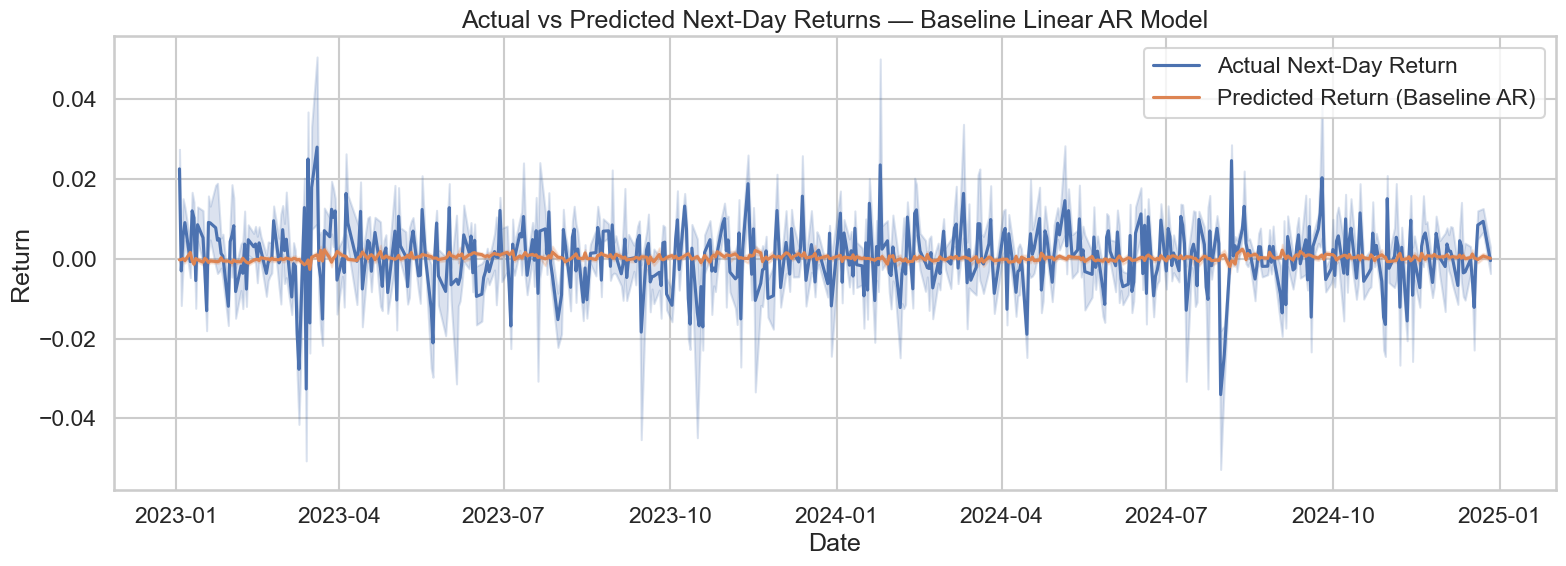

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = test_base.copy()
plot_df["pred_base"] = y_pred_base
plot_df = plot_df.sort_values("date")

sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(16,6))
sns.lineplot(x="date", y="target_ret_next", data=plot_df, label="Actual Next-Day Return")
sns.lineplot(x="date", y="pred_base", data=plot_df, label="Predicted Return (Baseline AR)")
plt.title("Actual vs Predicted Next-Day Returns — Baseline Linear AR Model")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.tight_layout()
plt.show()


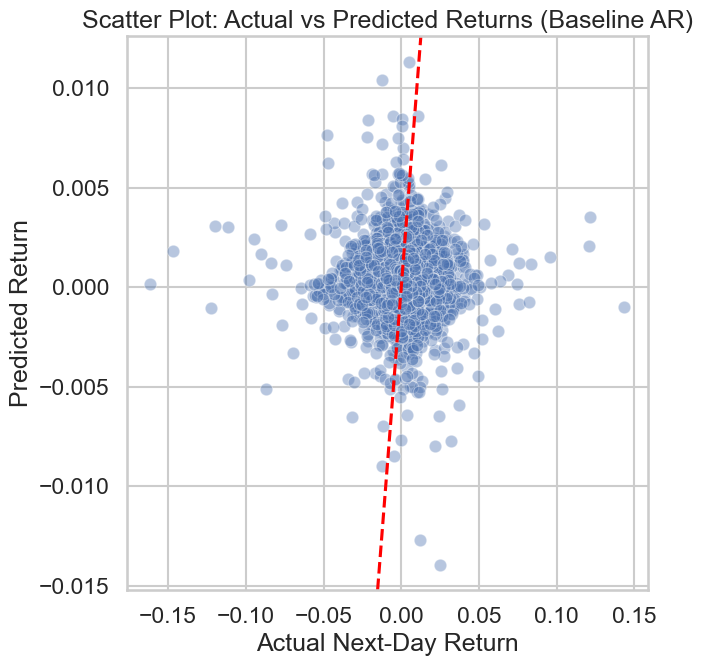

In [28]:
plt.figure(figsize=(7,7))
sns.scatterplot(x=plot_df["target_ret_next"], y=plot_df["pred_base"], alpha=0.4)
plt.axline((0,0), slope=1, color="red", linestyle="--")
plt.title("Scatter Plot: Actual vs Predicted Returns (Baseline AR)")
plt.xlabel("Actual Next-Day Return")
plt.ylabel("Predicted Return")
plt.tight_layout()
plt.show()


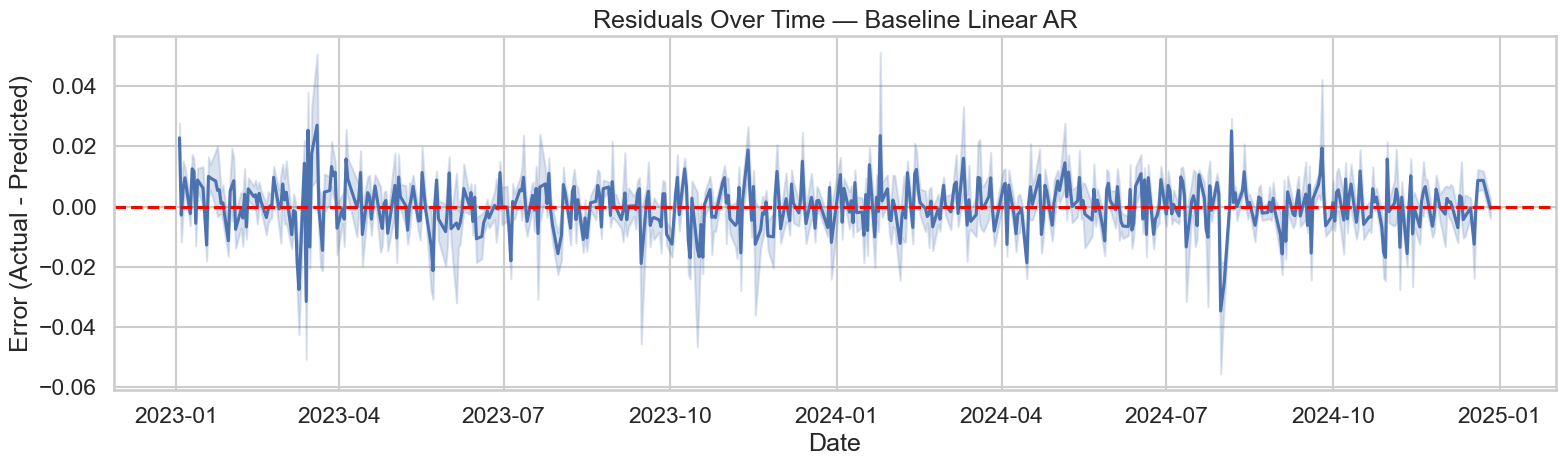

In [29]:
plot_df["residual"] = plot_df["target_ret_next"] - plot_df["pred_base"]

plt.figure(figsize=(16,5))
sns.lineplot(x="date", y="residual", data=plot_df)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals Over Time — Baseline Linear AR")
plt.xlabel("Date")
plt.ylabel("Error (Actual - Predicted)")
plt.tight_layout()
plt.show()


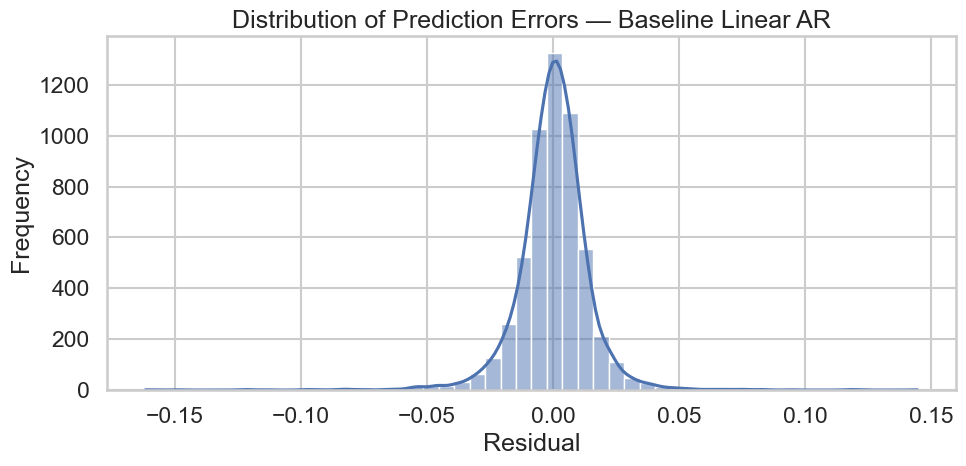

In [30]:
plt.figure(figsize=(10,5))
sns.histplot(plot_df["residual"], kde=True, bins=50)
plt.title("Distribution of Prediction Errors — Baseline Linear AR")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


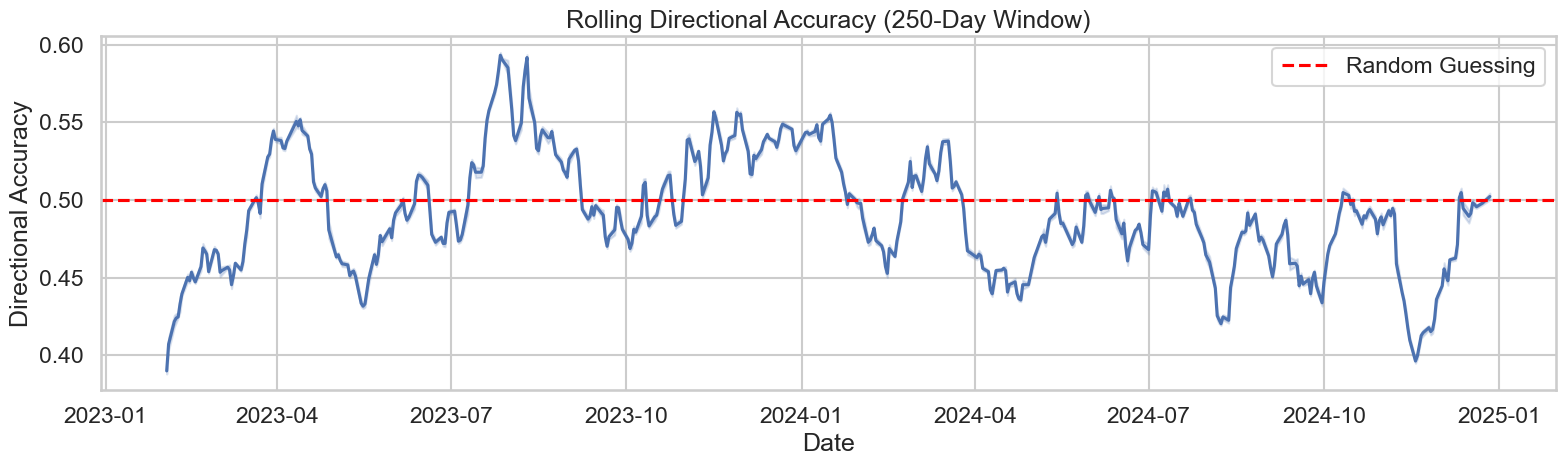

In [31]:
import numpy as np

plot_df["correct_dir"] = (
    np.sign(plot_df["target_ret_next"]) == np.sign(plot_df["pred_base"])
).astype(int)

plot_df["rolling_dir_acc"] = (
    plot_df["correct_dir"].rolling(250).mean()
)

plt.figure(figsize=(16,5))
sns.lineplot(x="date", y="rolling_dir_acc", data=plot_df)
plt.title("Rolling Directional Accuracy (250-Day Window)")
plt.xlabel("Date")
plt.ylabel("Directional Accuracy")
plt.axhline(0.5, color="red", linestyle="--", label="Random Guessing")
plt.legend()
plt.tight_layout()
plt.show()


In [32]:
prediction_sample = plot_df[[
    "date", "ticker", "target_ret_next", "pred_base", "residual"
]].head(20)

prediction_sample


,date,ticker,target_ret_next,pred_base,residual
1257,2023-01-03,ABB,0.033751,0.000015,0.033736
8289,2023-01-03,LONZA,0.015398,-0.000289,0.015687
6531,2023-01-03,JULIUS BAER,0.023491,-0.000415,0.023906
15321,2023-01-03,SWISSCOM,0.010861,-0.001122,0.011983
4773,2023-01-03,HELVETIA,0.019022,-0.001399,0.020421
11805,2023-01-03,SWATCH,0.019834,0.000939,0.018895
10047,2023-01-03,NESTLE,0.017260,-0.000067,0.017328
18837,2023-01-03,VONTOBEL,0.030255,-0.000888,0.031143
3015,2023-01-03,BKW ENERGIE,0.038251,0.001523,0.036728
13563,2023-01-03,SWISS LIFE,0.016803,-0.001061,0.017865


## Multimodal Linear AR + Sentiment Model

### Define multimodal feature set including sentiment

In [33]:
# Numeric mapping of categorical t-1 sentiment
sent_map = {"negative": -1, "neutral": 0, "positive": 1}
train_df["sent_cat_lag1_num"] = train_df["sent_cat_lag1"].map(sent_map)
test_df["sent_cat_lag1_num"] = test_df["sent_cat_lag1"].map(sent_map)

multimodal_features = baseline_features + [
    "sent_lag1",          # numeric t-1 sentiment
    "sent_cat_lag1_num",  # categorical t-1 sentiment mapped
    "sent_roll3"          # past sentiment trend
]

multimodal_features 

['ret_lag1',
 'ret_lag2',
 'ret_lag3',
 'ret_lag4',
 'ret_lag5',
 'vol21',
 'vol63',
 'vol21_lag1',
 'ret_ema21',
 'ret_ema63',
 'px_ma21',
 'px_ma63',
 'px_ma200',
 'trend200_up',
 'sent_lag1',
 'sent_cat_lag1_num',
 'sent_roll3']

### Drop NaNs only inside train/test

In [34]:
train_mm = train_df.dropna(subset=multimodal_features + ["target_ret_next"]).copy()
test_mm  = test_df.dropna(subset=multimodal_features + ["target_ret_next"]).copy()

X_train_mm = train_mm[multimodal_features]
y_train_mm = train_mm["target_ret_next"]

X_test_mm = test_mm[multimodal_features]
y_test_mm = test_mm["target_ret_next"]


### Scale multimodal features (train-only)

In [35]:
from sklearn.preprocessing import StandardScaler

scale_cols_mm = multimodal_features  # all numeric

scaler_mm = StandardScaler()
scaler_mm.fit(X_train_mm[scale_cols_mm])

X_train_mm_scaled = X_train_mm.copy()
X_test_mm_scaled = X_test_mm.copy()

X_train_mm_scaled[scale_cols_mm] = scaler_mm.transform(X_train_mm[scale_cols_mm])
X_test_mm_scaled[scale_cols_mm] = scaler_mm.transform(X_test_mm[scale_cols_mm])


### Fit multimodal linear model

In [36]:
lin_mm = LinearRegression()
lin_mm.fit(X_train_mm_scaled, y_train_mm)

y_pred_mm = lin_mm.predict(X_test_mm_scaled)


In [49]:
lin_mm = LinearRegression()
lin_mm.fit(X_train_mm_scaled, y_train_mm)

y_pred_mm = lin_mm.predict(X_test_mm_scaled)


### Evaluate multimodal model

In [37]:
mse_mm  = mean_squared_error(y_test_mm, y_pred_mm)
rmse_mm = np.sqrt(mse_mm)
mae_mm = mean_absolute_error(y_test_mm, y_pred_mm)
r2_mm = r2_score(y_test_mm, y_pred_mm)
dir_acc_mm = directional_accuracy(y_test_mm, y_pred_mm)

print("=== Linear AR + Sentiment (Multimodal) ===")
print(f"MSE : {mse_mm:.6f}")
print(f"RMSE: {rmse_mm:.6f}")
print(f"MAE : {mae_mm:.6f}")
print(f"R²  : {r2_mm:.4f}")
print(f"Directional accuracy: {dir_acc_mm:.4f}")



=== Linear AR + Sentiment (Multimodal) ===
MSE : 0.000212
RMSE: 0.014563
MAE : 0.009735
R²  : -0.0145
Directional accuracy: 0.4944


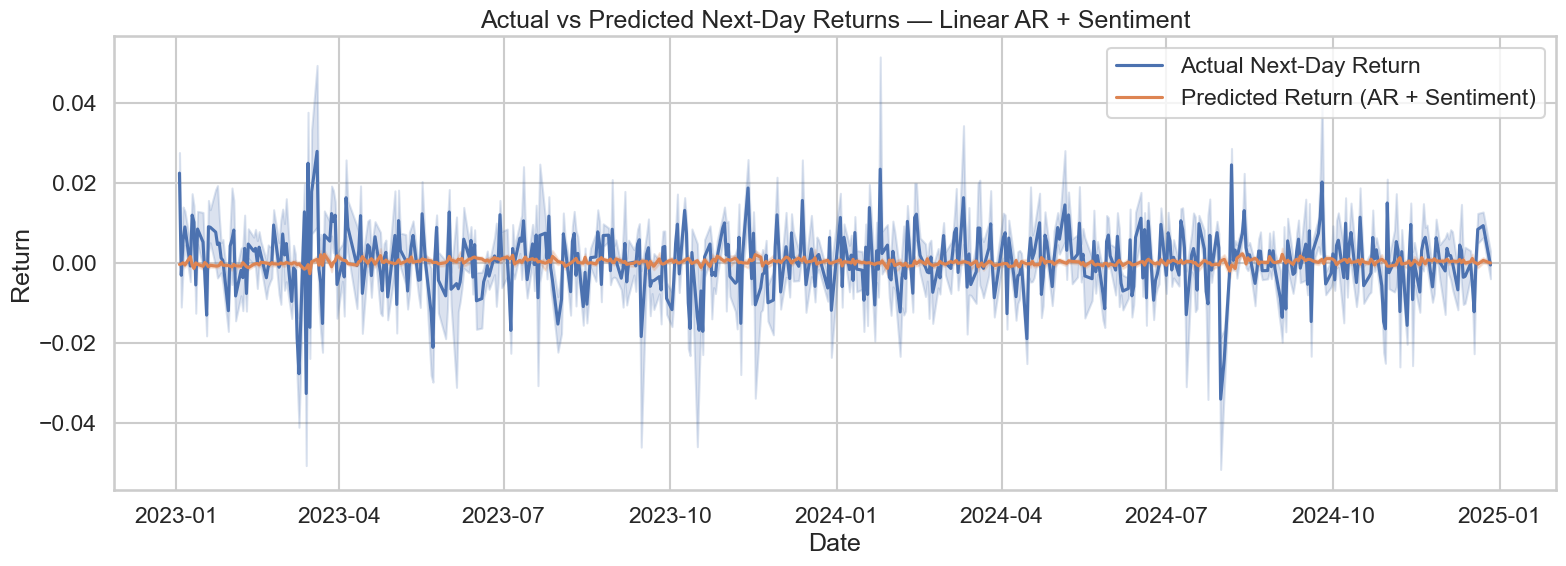

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_mm = test_mm.copy()
plot_mm["pred_mm"] = y_pred_mm
plot_mm = plot_mm.sort_values("date")

sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(16,6))
sns.lineplot(x="date", y="target_ret_next", data=plot_mm, label="Actual Next-Day Return")
sns.lineplot(x="date", y="pred_mm", data=plot_mm, label="Predicted Return (AR + Sentiment)")
plt.title("Actual vs Predicted Next-Day Returns — Linear AR + Sentiment")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.tight_layout()
plt.show()


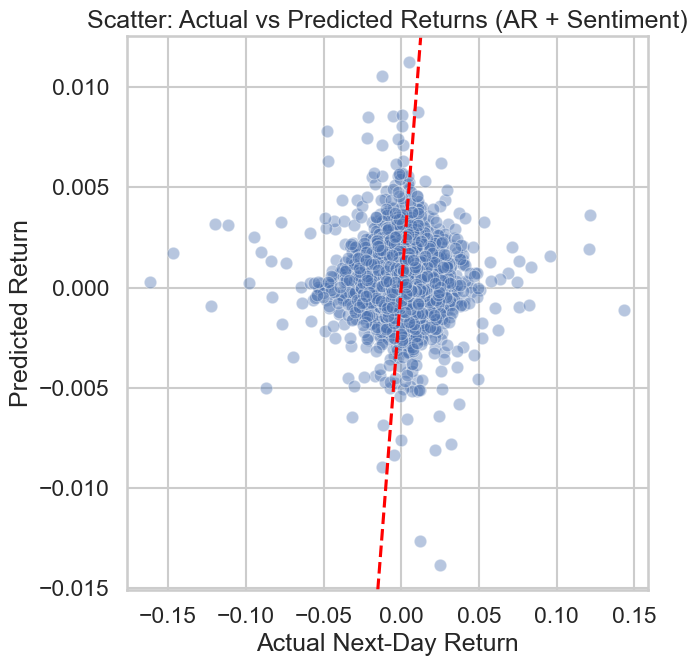

In [39]:
plt.figure(figsize=(7,7))
sns.scatterplot(x=plot_mm["target_ret_next"], y=plot_mm["pred_mm"], alpha=0.4)
plt.axline((0,0), slope=1, color="red", linestyle="--")
plt.title("Scatter: Actual vs Predicted Returns (AR + Sentiment)")
plt.xlabel("Actual Next-Day Return")
plt.ylabel("Predicted Return")
plt.tight_layout()
plt.show()


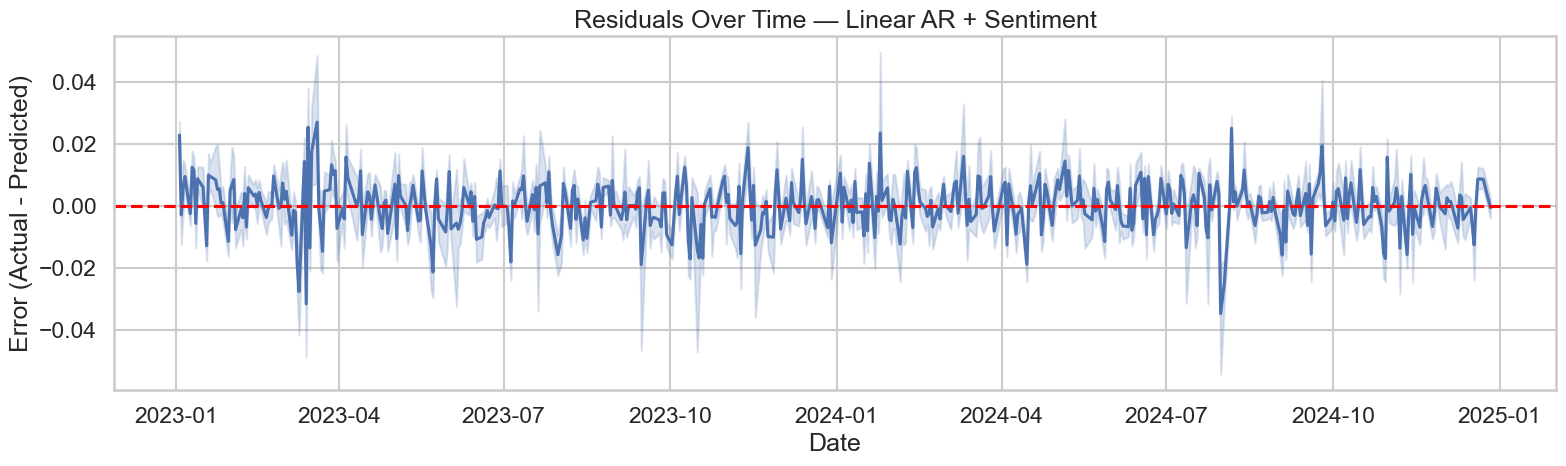

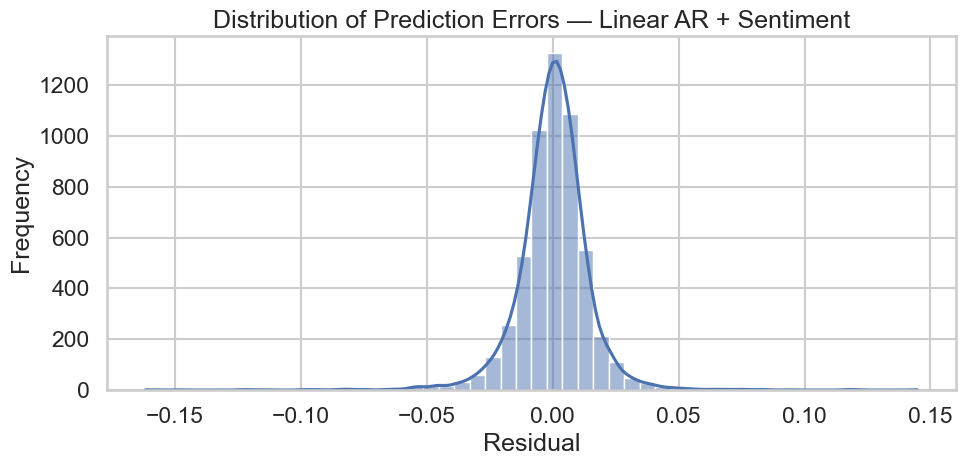

In [40]:
plot_mm["residual_mm"] = plot_mm["target_ret_next"] - plot_mm["pred_mm"]

# Residuals over time
plt.figure(figsize=(16,5))
sns.lineplot(x="date", y="residual_mm", data=plot_mm)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals Over Time — Linear AR + Sentiment")
plt.xlabel("Date")
plt.ylabel("Error (Actual - Predicted)")
plt.tight_layout()
plt.show()

# Error distribution
plt.figure(figsize=(10,5))
sns.histplot(plot_mm["residual_mm"], kde=True, bins=50)
plt.title("Distribution of Prediction Errors — Linear AR + Sentiment")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


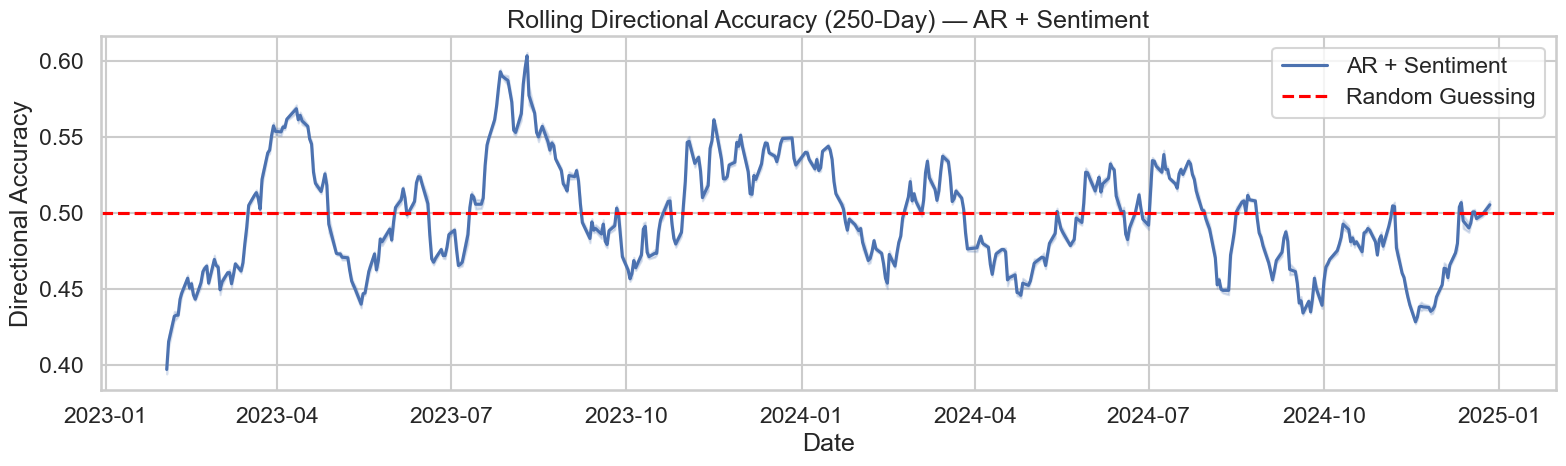

In [41]:
import numpy as np

plot_mm["correct_dir_mm"] = (
    np.sign(plot_mm["target_ret_next"]) == np.sign(plot_mm["pred_mm"])
).astype(int)

plot_mm["rolling_dir_acc_mm"] = plot_mm["correct_dir_mm"].rolling(250).mean()

plt.figure(figsize=(16,5))
sns.lineplot(x="date", y="rolling_dir_acc_mm", data=plot_mm, label="AR + Sentiment")
plt.axhline(0.5, color="red", linestyle="--", label="Random Guessing")
plt.title("Rolling Directional Accuracy (250-Day) — AR + Sentiment")
plt.xlabel("Date")
plt.ylabel("Directional Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


In [42]:
prediction_sample_mm = plot_mm[[
    "date",
    "ticker",
    "target_ret_next",
    "pred_mm",
    "residual_mm"
]].head(20)

prediction_sample_mm


,date,ticker,target_ret_next,pred_mm,residual_mm
1257,2023-01-03,ABB,0.033751,-0.000123,0.033874
8289,2023-01-03,LONZA,0.015398,-0.000172,0.015570
6531,2023-01-03,JULIUS BAER,0.023491,-0.000336,0.023827
15321,2023-01-03,SWISSCOM,0.010861,-0.001279,0.012140
4773,2023-01-03,HELVETIA,0.019022,-0.001547,0.020569
11805,2023-01-03,SWATCH,0.019834,0.000826,0.019008
10047,2023-01-03,NESTLE,0.017260,-0.000215,0.017475
18837,2023-01-03,VONTOBEL,0.030255,-0.000810,0.031065
3015,2023-01-03,BKW ENERGIE,0.038251,0.001398,0.036853
13563,2023-01-03,SWISS LIFE,0.016803,-0.001226,0.018029


## Analysis

### Per-company model performance

In [43]:
# Create dataframe with true and predicted values for BOTH models
cmp = test_base[["row_id", "date", "ticker", "target_ret_next"]].copy()
cmp["pred_base"] = y_pred_base

tmp_mm = test_mm[["row_id"]].copy()
tmp_mm["pred_mm"] = y_pred_mm

cmp = cmp.merge(tmp_mm, on="row_id", how="inner")

# Compute direction accuracy per company for ALL companies, and show the full table (not just first 3)
from sklearn.metrics import mean_squared_error

company_metrics = (
    cmp.groupby("ticker")
       .apply(lambda df: pd.Series({
           "RMSE_base":  np.sqrt(mean_squared_error(df["target_ret_next"], df["pred_base"])),
           "RMSE_mm":    np.sqrt(mean_squared_error(df["target_ret_next"], df["pred_mm"])),
           "DirAcc_base": np.mean(np.sign(df["target_ret_next"]) == np.sign(df["pred_base"])),
           "DirAcc_mm":   np.mean(np.sign(df["target_ret_next"]) == np.sign(df["pred_mm"])),
       }))
       .reset_index()
)

# Display the entire company_metrics table sorted by DirAcc_mm descending
display(company_metrics.sort_values("DirAcc_mm", ascending=False).reset_index(drop=True))


C:\Users\mkcak\AppData\Local\Temp\ipykernel_25568\1212261374.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


,ticker,RMSE_base,RMSE_mm,DirAcc_base,DirAcc_mm
0,LONZA,0.020819,0.020822,0.494,0.516
1,HELVETIA,0.011506,0.011510,0.492,0.512
2,SWISS LIFE,0.011663,0.011673,0.510,0.504
3,UBS,0.017546,0.017544,0.496,0.500
4,NESTLE,0.009838,0.009836,0.506,0.500
5,SWATCH,0.017408,0.017412,0.488,0.492
6,JULIUS BAER,0.017664,0.017669,0.490,0.492
7,VONTOBEL,0.012250,0.012248,0.480,0.492
8,BKW ENERGIE,0.014158,0.014161,0.480,0.490
9,ABB,0.013797,0.013799,0.488,0.474


### CAP-LEVEL Performance (Small / Mid / Large Cap)

In [44]:
# Attach cap info to cmp
cmp_cap = cmp.merge(features_model[["row_id", "cap"]], on="row_id", how="left")

cap_metrics = (
    cmp_cap.groupby("cap")
           .apply(lambda df: pd.Series({
               "RMSE_base":  np.sqrt(mean_squared_error(df["target_ret_next"], df["pred_base"])),
               "RMSE_mm":    np.sqrt(mean_squared_error(df["target_ret_next"], df["pred_mm"])),
               "DirAcc_base": np.mean(np.sign(df["target_ret_next"]) == np.sign(df["pred_base"])),
               "DirAcc_mm":   np.mean(np.sign(df["target_ret_next"]) == np.sign(df["pred_mm"])),
           }))
           .reset_index()
)

cap_metrics


C:\Users\mkcak\AppData\Local\Temp\ipykernel_25568\2490693808.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


,cap,RMSE_base,RMSE_mm,DirAcc_base,DirAcc_mm
0,Large Cap,0.014967,0.014974,0.50000,0.498
1,Mid Cap,0.013797,0.013799,0.48800,0.474
2,Small Cap,0.014551,0.014552,0.48575,0.496


### SECTOR-LEVEL Performance

In [45]:
# Attach sector info to cmp
cmp_sector = cmp.merge(features_model[["row_id", "sector"]], on="row_id", how="left")

sector_metrics = (
    cmp_sector.groupby("sector")
              .apply(lambda df: pd.Series({
                  "RMSE_base":  np.sqrt(mean_squared_error(df["target_ret_next"], df["pred_base"])),
                  "RMSE_mm":    np.sqrt(mean_squared_error(df["target_ret_next"], df["pred_mm"])),
                  "DirAcc_base": np.mean(np.sign(df["target_ret_next"]) == np.sign(df["pred_base"])),
                  "DirAcc_mm":   np.mean(np.sign(df["target_ret_next"]) == np.sign(df["pred_mm"])),
              }))
              .reset_index()
)

sector_metrics.sort_values("DirAcc_mm", ascending=False)


C:\Users\mkcak\AppData\Local\Temp\ipykernel_25568\1829873319.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


,sector,RMSE_base,RMSE_mm,DirAcc_base,DirAcc_mm
3,Health Care,0.020819,0.020822,0.494000,0.516000
4,Insurance,0.011585,0.011592,0.501000,0.508000
2,Consumer Staples,0.009838,0.009836,0.506000,0.500000
0,Banking,0.016020,0.016021,0.488667,0.494667
1,Consumer Discretionary,0.017408,0.017412,0.488000,0.492000
5,Real Estate - Energy - Industrials,0.013979,0.013981,0.484000,0.482000
6,Technology,0.008349,0.008348,0.450000,0.466000


## Save Models / Metrics / Results

In [50]:
# === SAVE: Linear models + scalers ===

joblib.dump(lin_base,    LIN_MODELS_DIR / "lin_base_market_only.pkl")
joblib.dump(scaler_base, LIN_MODELS_DIR / "scaler_base.pkl")

joblib.dump(lin_mm,      LIN_MODELS_DIR / "lin_mm_multimodal.pkl")
joblib.dump(scaler_mm,   LIN_MODELS_DIR / "scaler_mm.pkl")

print("Saved linear AR models and scalers:")
print(" - lin_base_market_only.pkl")
print(" - scaler_base.pkl")
print(" - lin_mm_multimodal.pkl")
print(" - scaler_mm.pkl")


Saved linear AR models and scalers:
 - lin_base_market_only.pkl
 - scaler_base.pkl
 - lin_mm_multimodal.pkl
 - scaler_mm.pkl


In [51]:
# === SAVE: overall metrics for linear AR models ===

overall_metrics_lin = pd.DataFrame([
    {
        "model_id": "lin_base_market_only",
        "type": "baseline",
        "MSE": mse_base,
        "RMSE": rmse_base,
        "MAE": mae_base,
        "R2": r2_base,
        "DirAcc": dir_acc_base,
    },
    {
        "model_id": "lin_mm_multimodal",
        "type": "multimodal",
        "MSE": mse_mm,
        "RMSE": rmse_mm,
        "MAE": mae_mm,
        "R2": r2_mm,
        "DirAcc": dir_acc_mm,
    }
])

overall_metrics_lin.to_csv(LIN_RESULTS_DIR / "overall_metrics_linear.csv", index=False)
overall_metrics_lin


,model_id,type,MSE,RMSE,MAE,R2,DirAcc
0,lin_base_market_only,baseline,0.000212,0.014561,0.009733,-0.014180,0.488545
1,lin_mm_multimodal,multimodal,0.000212,0.014563,0.009735,-0.014497,0.494364


In [52]:
# === SAVE: prediction comparison + metrics tables ===

# 1) Save cmp (row-level predictions for both models)
cmp.to_parquet(LIN_RESULTS_DIR / "cmp_linear_base_vs_mm.parquet")

# Optionally add cap & sector info for richer analysis later
cmp_full_lin = cmp.merge(
    features_model[["row_id", "cap", "sector"]],
    on="row_id",
    how="left"
)
cmp_full_lin.to_parquet(LIN_RESULTS_DIR / "cmp_linear_base_vs_mm_full.parquet")

# 2) Save company / cap / sector metrics
company_metrics.to_csv(LIN_RESULTS_DIR / "company_metrics_linear.csv", index=False)
cap_metrics.to_csv(LIN_RESULTS_DIR / "cap_metrics_linear.csv", index=False)
sector_metrics.to_csv(LIN_RESULTS_DIR / "sector_metrics_linear.csv", index=False)

print("Saved linear AR detailed results:")
print(" - cmp_linear_base_vs_mm.parquet")
print(" - cmp_linear_base_vs_mm_full.parquet")
print(" - company_metrics_linear.csv")
print(" - cap_metrics_linear.csv")
print(" - sector_metrics_linear.csv")


Saved linear AR detailed results:
 - cmp_linear_base_vs_mm.parquet
 - cmp_linear_base_vs_mm_full.parquet
 - company_metrics_linear.csv
 - cap_metrics_linear.csv
 - sector_metrics_linear.csv
